In [1]:
from datasets import load_dataset, Dataset, Image as Img
import glob
import os
import cv2
from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

## Model settings, toknizer

In [2]:
checkpoint = "microsoft/git-base"
tokenizer_pth = "./svg_tokenizer"
MAX_LEN = 1000

In [3]:
from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained(checkpoint)

/home/lanv/venv/lib64/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/lanv/venv/lib64/python3.12/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
model_bytes = model.get_memory_footprint()
display(f"Model takes roughly {round(model_bytes * 1e-9, 2)} GB")

'Model takes roughly 0.71 GB'

In [5]:
from transformers import AutoProcessor, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(tokenizer_pth)
tokenizer.model_max_length = MAX_LEN

processor = AutoProcessor.from_pretrained(checkpoint)
processor.tokenizer = tokenizer
    
def tokenize(batch):
    return tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN)

In [6]:
icons = "clean_icons"
images = "clean_images"

svgs = []
pngs = []

ma = 1000000

for f in glob.glob(os.path.join("data", icons,"*.svg")):
  img = (f.split("/")[-1].split(".")[0])

  if(len(open(f).read()) < MAX_LEN):
    svgs.append(os.path.join("data", icons, img+".svg"))
    pngs.append(os.path.join("data", images, img+".png"))
  
    ma -= 1
    if(ma == 0):
      break

In [7]:
def path_to_encoded(d_in):
  text = open(d_in).read()
  return {"labels": text}

def to_rgb(im_in):
  return {"pixel_values":im_in.convert("RGB")}

ds = (
    Dataset
    .from_dict({
    "svg": svgs,
    "png": pngs
    })
    .cast_column("png", Img())
    .rename_column("png","pixel_values")
    .rename_column("svg","labels")
    # .train_test_split(test_size=0.1)
    .map(path_to_encoded, desc="read and tokenize SVG", input_columns="labels")
    .map(to_rgb, desc="convert images", input_columns="pixel_values")
  )
ds.set_format("torch")
ds

read and tokenize SVG:   0%|          | 0/6892 [00:00<?, ? examples/s]

convert images:   0%|          | 0/6892 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'pixel_values'],
    num_rows: 6892
})

In [8]:
class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        encoding = self.processor(images=item["pixel_values"], text=item["labels"], padding="max_length", return_tensors="pt")

        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}

        return encoding

train_dataset = ImageCaptioningDataset(ds, processor)

In [9]:
print(ds[0].keys())
ds[0]["pixel_values"].shape

dict_keys(['labels', 'pixel_values'])


torch.Size([3, 256, 256])

In [10]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=4)

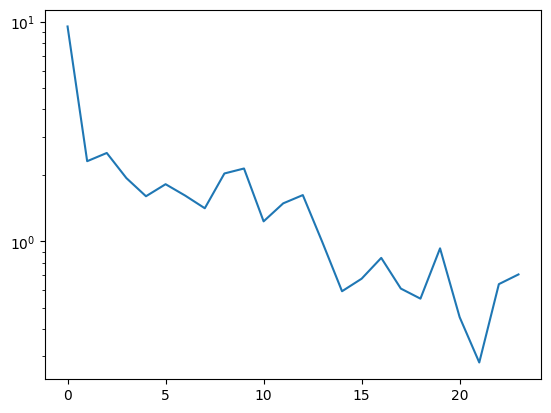

Unused or unrecognized kwargs: padding.


0 Loss: 0.7077033519744873


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
model.to(device)
model.train()
losses = []

EPOCHS = 50

# with tqdm(total=EPOCHS * len(train_dataloader), position=0, leave=True) as pbar:
for epoch in range(EPOCHS):
  for idx, batch in enumerate(train_dataloader):
    input_ids = batch.pop("input_ids").to(device)
    pixel_values = batch.pop("pixel_values").to(device)
    att_mask = batch.pop("attention_mask").to(device)

    outputs = model(input_ids=input_ids, pixel_values=pixel_values, labels=input_ids, attention_mask=att_mask)

    loss = outputs.loss
    loss.backward()

    optimizer.step()
    optimizer.zero_grad()

    # logging
    if(idx % 20 == 0):
      l = loss.cpu().item()
      losses.append(l)
      clear_output()
      ax = plt.subplot()
      ax.plot(losses)
      ax.set_yscale("log")
      plt.show()
      print(f"{epoch} Loss: {l}")
      if(l == min(losses)):
        torch.save(model.state_dict(), f"svgmodel-2.pth")
    if(idx % 100 == 0):
      generated_ids = model.generate(pixel_values=pixel_values[0].unsqueeze(0), max_length=MAX_LEN)
      generated_captions = processor.batch_decode(generated_ids[0], skip_special_tokens=True)
      with open("samples.txt", "a") as f:
        f.write(f"{idx*(epoch + 1)}, {"".join(generated_captions)}\n")

    
    # pbar.update(len(input_ids))




In [ ]:
# save 
# torch.save(model.state_dict(), f"svgmodel_{epoch}.pth")